In [1]:
import pandas as pd
from pathlib import Path


# Combining all individual season csvs we got from NHL_scrape.ipynb to one csv

data_folder = Path.cwd()/"NHL Season CSVs"
csv_combine = list(data_folder.glob("*.csv"))
combined_df = pd.concat([pd.read_csv(f) for f in csv_combine])

In [ ]:
# Saving the combined CSV
combined_df.to_csv("NHL_seasons_combined.csv", index = False)

*NHL_seasons_combined.csv I used for the further analysis is provided in the github repository*

In [3]:
# Reading the new CSV and saving it as df
df = pd.read_csv("NHL_seasons_combined.csv")

## Cleaning the dataset, fixing datatypes, adding relevant columns

In [4]:
# Changing datatype of some columns
df["OL"] = df["OL"].astype("Int64") # using "Int64" to keep NaN values. It helps me keep the years in which the game could end up in a draw separated.
df["Rk"] = df["Rk"].astype("Int64")

In [5]:
# Checking all the teams in the dataframe
for team in sorted(df["TEAM"].unique()):
    print(team)

Anaheim Ducks
Arizona Coyotes
Atlanta Thrashers
Boston Bruins
Buffalo Sabres
Calgary Flames
Carolina Hurricanes
Chicago Blackhawks
Colorado Avalanche
Columbus Blue Jackets
Dallas Stars
Detroit Red Wings
Edmonton Oilers
Florida Panthers
Hartford Whalers
League Average
Los Angeles Kings
Mighty Ducks of Anaheim
Minnesota North Stars
Minnesota Wild
Montreal Canadiens
Nashville Predators
New Jersey Devils
New York Islanders
New York Rangers
Ottawa Senators
Philadelphia Flyers
Phoenix Coyotes
Pittsburgh Penguins
Quebec Nordiques
San Jose Sharks
Seattle Kraken
St. Louis Blues
Tampa Bay Lightning
Toronto Maple Leafs
Utah Hockey Club
Vancouver Canucks
Vegas Golden Knights
Washington Capitals
Winnipeg Jets


In [6]:
# Two teams rebranded from 1990 to 2025, replacing the old names and keeping just the new one. If I wanted to keep the history accurate names I would probably need to add ID to each team.
# (This doesn't deal with teams that completely relocated to a different city)
df["TEAM"] = df["TEAM"].replace("Mighty Ducks of Anaheim", "Anaheim Ducks")
df["TEAM"] = df["TEAM"].replace("Phoenix Coyotes", "Arizona Coyotes")


In [7]:
# Adding a column with Goals per game
df["GpG"] = ((df["GF"]+df["GA"])/df["GP"]).round(2)
# Adding a column with win percentage
df["WIN%"] = (df["W"]/df["GP"]*100).round(2)

*We will be working with data from 1990 to 2025, there are metrics like overtime loss, or average age that were not measured in all the seasons. The specific of the dataset is also that in each season table we joined together is a League Average row that we will need to filter out for some exercises. I already added columns with win percentage metric that I will need for one of the exercises and goals per game metric that I want to explore myself*

## Analysis of Team Participation in League Seasons

**How many teams participated over the years**

In [8]:
participants = df["TEAM"].nunique()
print(f"{participants} teams participated in total over the years")

38 teams participated in total over the years


**Teams that participated in most seasons**

In [9]:
participation = df["TEAM"].value_counts()

# Droping the League Average row
participation = participation.drop("League Average")

print(f"Count of seasons teams partook in: \n{participation}")

Count of seasons teams partook in: 
TEAM
Boston Bruins            35
Toronto Maple Leafs      35
Calgary Flames           35
Detroit Red Wings        35
Philadelphia Flyers      35
Pittsburgh Penguins      35
New York Islanders       35
Los Angeles Kings        35
Washington Capitals      35
Vancouver Canucks        35
St. Louis Blues          35
Buffalo Sabres           35
New Jersey Devils        35
New York Rangers         35
Chicago Blackhawks       35
Edmonton Oilers          35
Montreal Canadiens       35
San Jose Sharks          33
Tampa Bay Lightning      32
Ottawa Senators          32
Dallas Stars             31
Florida Panthers         31
Anaheim Ducks            31
Colorado Avalanche       29
Arizona Coyotes          27
Carolina Hurricanes      27
Nashville Predators      26
Minnesota Wild           24
Columbus Blue Jackets    24
Winnipeg Jets            21
Atlanta Thrashers        11
Hartford Whalers          8
Vegas Golden Knights      8
Quebec Nordiques          6
Minneso

**Showing only teams that participated in every season of the dataset**

In [10]:
# Getting the total amount of seasons in the dataframe
season_count = df["YEAR"].nunique()

# Filtering only the teams that match the season count
full_participation = participation[participation == season_count]

print(f"Teams that particiapted in all seasons of the dataset:\n{full_participation}")

Teams that particiapted in all seasons of the dataset:
TEAM
Boston Bruins          35
Toronto Maple Leafs    35
Calgary Flames         35
Detroit Red Wings      35
Philadelphia Flyers    35
Pittsburgh Penguins    35
New York Islanders     35
Los Angeles Kings      35
Washington Capitals    35
Vancouver Canucks      35
St. Louis Blues        35
Buffalo Sabres         35
New Jersey Devils      35
New York Rangers       35
Chicago Blackhawks     35
Edmonton Oilers        35
Montreal Canadiens     35
Name: count, dtype: int64


**How many teams participated in all seasons**

In [11]:
print(f"{full_participation.count()} teams have participated in all {season_count} seasons")

17 teams have participated in all 35 seasons


## Best Performing Teams in League History

**Teams with highest average win percentage**

In [12]:
highest_avg_win = df.groupby('TEAM')['WIN%'].mean().sort_values(ascending=False).round(2)
print(f"Top 5 teams with the highest average win percentage\n{highest_avg_win.head(5)}")

Top 5 teams with the highest average win percentage
TEAM
Vegas Golden Knights    58.94
Colorado Avalanche      52.55
Boston Bruins           52.47
Pittsburgh Penguins     52.13
Dallas Stars            52.06
Name: WIN%, dtype: float64


*Vegas Golden Knights have much higher average win percentage than the following teams. It could be because they are a newer team with only 8 seasons recorded, but that's just a hypotesis.*

**Seasons where the winner had the highest win percentage**

In [13]:
rk1_teams = df[df['Rk'] == 1]
dominant_seasons = rk1_teams.sort_values(by="WIN%", ascending=False)[["YEAR", "TEAM", "WIN%"]].head(5)
print(dominant_seasons)

     YEAR                  TEAM   WIN%
941  2023         Boston Bruins  79.27
146  1996     Detroit Red Wings  75.61
812  2019   Tampa Bay Lightning  75.61
625  2013    Chicago Blackhawks  75.00
876  2021  Vegas Golden Knights  71.43


## Top Teams in History

**Teams that won the regular season the most times**

In [14]:
most_rk1_teams = rk1_teams["TEAM"].value_counts()
print(f"Top5 teams with most regular season wins: \n{most_rk1_teams.head(5)}")

Top5 teams with most regular season wins: 
TEAM
Detroit Red Wings      6
Boston Bruins          4
New York Rangers       4
Washington Capitals    3
Vancouver Canucks      2
Name: count, dtype: int64


**Teams that never won the regular season**

In [15]:
# Getting all the winner teams
winner_teams = df[df["Rk"] == 1]["TEAM"]

# Getting all the teams that are NOT in the winner_teams variable
never_rk1_teams = df[~df["TEAM"].isin(winner_teams)]['TEAM'].unique()

print(f"Teams that never won the regular season: \n{never_rk1_teams}")

Teams that never won the regular season: 
['Calgary Flames' 'Montreal Canadiens' 'Edmonton Oilers'
 'Hartford Whalers' 'New Jersey Devils' 'Toronto Maple Leafs'
 'Minnesota North Stars' 'Los Angeles Kings' 'New York Islanders'
 'Philadelphia Flyers' 'Quebec Nordiques' 'League Average' 'Anaheim Ducks'
 'Arizona Coyotes' 'Carolina Hurricanes' 'Atlanta Thrashers'
 'Columbus Blue Jackets' 'Minnesota Wild' 'Seattle Kraken'
 'Utah Hockey Club']


**Teams with most play-off appearences**

In [16]:
po_teams = df[df["PO"]=="YES"]
po_appearences = po_teams["TEAM"].value_counts()
print(f"Top5 teams with most play-off appearences:\n{po_appearences.head(5)}")

Top5 teams with most play-off appearences:
TEAM
Boston Bruins          27
St. Louis Blues        27
Washington Capitals    27
Pittsburgh Penguins    27
Detroit Red Wings      25
Name: count, dtype: int64


## Overtime losses

**Total count of overtime losses by a team**

In [17]:
# Until 1999 the game could end in a draw, filtering the dataframe to drop years that are not relevant
OL_df = df[~df['YEAR'].between(1990, 1999)]

team_total_ol = OL_df.groupby('TEAM')['OL'].sum().sort_values(ascending=False)

print(f'Total count of overtime losses by team: \n{team_total_ol}')

Total count of overtime losses by team: 
TEAM
Florida Panthers         232
Philadelphia Flyers      228
Boston Bruins            226
Anaheim Ducks            221
Detroit Red Wings        220
Montreal Canadiens       219
New York Islanders       213
San Jose Sharks          213
Chicago Blackhawks       209
Los Angeles Kings        207
Toronto Maple Leafs      206
Washington Capitals      205
Carolina Hurricanes      203
Vancouver Canucks        201
St. Louis Blues          199
League Average           199
Buffalo Sabres           198
New Jersey Devils        198
Calgary Flames           197
Dallas Stars             197
Pittsburgh Penguins      197
Columbus Blue Jackets    196
Ottawa Senators          195
Edmonton Oilers          193
Nashville Predators      191
Arizona Coyotes          191
Minnesota Wild           188
New York Rangers         183
Tampa Bay Lightning      180
Colorado Avalanche       167
Winnipeg Jets             99
Atlanta Thrashers         78
Vegas Golden Knights      

**Identifying the team that lost the most often in overtime**

In [18]:
# Comparing teams total overtime losses to their total games played
ol_loss_ratio = OL_df.groupby('TEAM')[['OL', 'GP']].sum()
ol_loss_ratio["OL%"]=(ol_loss_ratio["OL"]/ol_loss_ratio["GP"]*100).round(2)

print(f'Top5 teams loosing in overtime most frequently: \n{ol_loss_ratio.sort_values(by="OL%", ascending=False).head(5)}')

Top5 teams loosing in overtime most frequently: 
                      OL    GP    OL%
TEAM                                 
Utah Hockey Club      13    82  15.85
Florida Panthers     232  1977  11.73
Philadelphia Flyers  228  1977  11.53
Boston Bruins        226  1978  11.43
Anaheim Ducks        221  1979  11.17


*Similarly to the average win percentage, the team on top has much higher percentage than the rest of the top5, but again, Utah Hockey Club is a new team with only one season recorded so far.*

**Percentage of teams that lost in overtime at least once**

In [19]:
#Getting number of unique teams in the dataframe
all_unique_teams = OL_df["TEAM"].nunique()

# Filtering the teams that have OL count higher than 0 in team_total_ol variable, defined in the Total count of overtime losses exercise.
ol_loss_teams = team_total_ol[team_total_ol > 0].count()

# Getting percentage of teams with at least one OL loss
ol_team_pct = (ol_loss_teams/all_unique_teams) * 100

print(f"{ol_team_pct}% of teams lost at least one game in overtime.")


100.0% of teams lost at least one game in overtime.


**Season with the most overtimes**

In [20]:
ol_by_season = OL_df.groupby("YEAR")["OL"].sum().sort_values(ascending=False)

print(f'Top5 seasons with the most overtime played \n{ol_by_season.head(5)}')

Top5 seasons with the most overtime played 
YEAR
2014    317
2015    316
2010    311
2023    311
2012    310
Name: OL, dtype: Int64


# Goals ratio

In [21]:
# Adding a column with goals ratio to the dataframe
df["GR"] = (df["GF"]/df["GA"]).round(3)
# Excluding League Average rows from the dataframe for this part of analysis
gr_df = df[df["TEAM"]!= "League Average"]

**Description of goals ratio**

In [22]:
ratio_summary = gr_df["GR"].describe()
print(ratio_summary)

count    1005.000000
mean        1.018863
std         0.188309
min         0.506000
25%         0.887000
50%         1.018000
75%         1.141000
max         1.796000
Name: GR, dtype: float64


*We can see that mean and median are very close together, this indicates that the dataset has normal distribution without any big outliers. This result should be expected, in a complete NHL league table, total goals scored should always equal total goals received.*

*What does the ratio tell us in general:*
  - *Values that are higher than 1.000 mean that the team scored more goals than they received while values lower than 1.000 mean the opposite.*
  - *We can use this ratio as an indication of dominance, teams with high numbers score much more goals than they receive, winning more games.*
  - *Because the ratio indicates how dominant a team is, we can probably expect that the values higher than 1.000 will be usually found towards the top of the season table.*

## Distribution of the Goals Ratio variable

**Histogram for the "GR" variable**

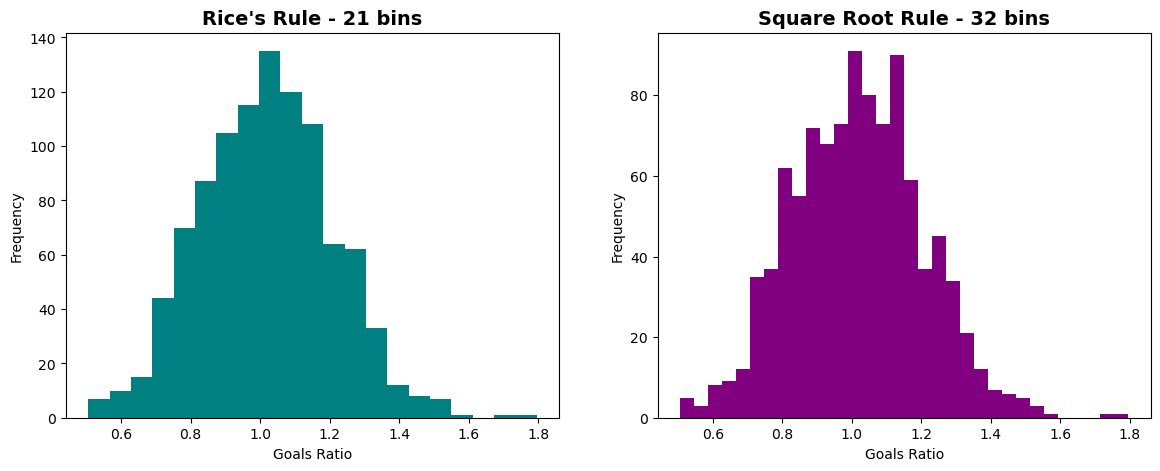

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Getting n for the bins calculation
goals_ratio = gr_df["GR"]  
n = len(goals_ratio)

# 2. Calculate the number of bins
rice_bins = int(np.ceil(2 * (n ** (1/3))))  # 21 bins
square_bins = int(np.ceil(np.sqrt(n)))      # 32 bins

# 3. Creating a plot with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Rice's Rule
axes[0].hist(goals_ratio, bins=rice_bins, color="teal")
axes[0].set_title(f"Rice's Rule - {rice_bins} bins", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Goals Ratio")
axes[0].set_ylabel("Frequency")

# Plot 2 - Square Root Rule
axes[1].hist(goals_ratio, bins=square_bins, color="purple")
axes[1].set_title(f"Square Root Rule - {square_bins} bins", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Goals Ratio")
axes[1].set_ylabel("Frequency")

plt.show()

## Victory Percentage

**Description of win percenage column**

In [24]:
win_pct_summary = gr_df["WIN%"].describe()
print(win_pct_summary)

count    1005.000000
mean       47.475204
std        10.461735
min        11.900000
25%        40.240000
50%        47.560000
75%        54.880000
max        79.270000
Name: WIN%, dtype: float64


*Again the mean and median are close together, indicating standard data distribution without outliers and the behaviour is expected*

*At first look, I didn't understand why the mean and median aren't at 50%. Nowadays, a win for a team automatically means that the oposing team lost, however, in portion of the dataset(from 1990 to 1999) a third outcome, a draw, was possible, as already mentioned. This drives the mean and median below 50%*

**Histogram for win percentage with set bins number**

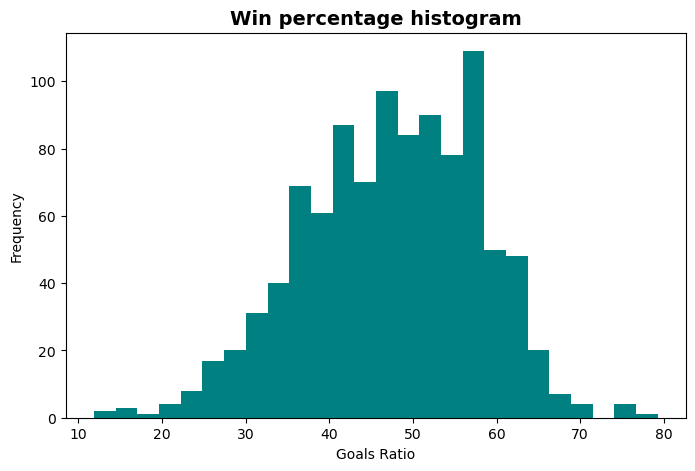

In [25]:
# Creating the plot
plt.figure(figsize=(8,5))

# Histogram with an arbitrary number of bins
plt.hist(gr_df["WIN%"], bins=26, color="teal")
plt.title("Win percentage histogram", fontsize=14, fontweight="bold")
plt.xlabel("Goals Ratio")
plt.ylabel("Frequency")

plt.show()

**Correlation between win percentage and goal ratio**

In [26]:
win_gr_correlation = gr_df["WIN%"].corr(gr_df["GR"])
print(win_gr_correlation)

0.8864856322059557


*The correlation is very strong, this indicates that with incresing goals ratio your chance to win*
*the game also grows*

**Scatterplot for the correlation**

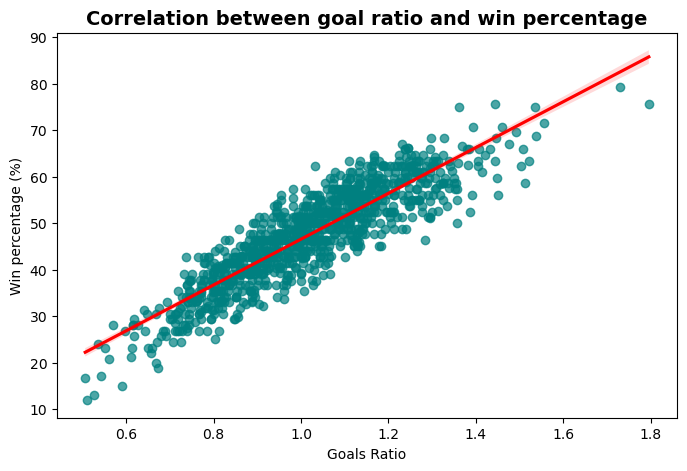

In [27]:
import seaborn as sns

# Creating the plot
plt.figure(figsize=(8, 5))

# Setting the data source, defining axes and visuals of the plot
sns.regplot(
    data=gr_df,
    x="GR",
    y="WIN%", 
    scatter_kws={"color": "teal", "alpha": 0.7},
    line_kws={"color": "red"},
)

# Setting the title of the plot and naming the axes
plt.title("Correlation between goal ratio and win percentage", fontsize=14, fontweight="bold")
plt.xlabel("Goals Ratio")
plt.ylabel("Win percentage (%)")


plt.show()

# Correlation between Shots and Goals For

In [28]:
shots_gf_correlation = gr_df["S"].corr(gr_df["GF"])
print(shots_gf_correlation)

0.7415210729900207


**Shots/Goals For Scatterplot**

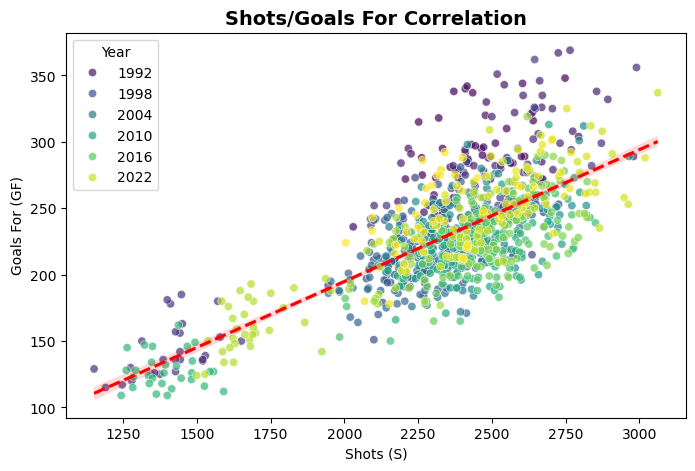

In [29]:
# Creating plot
plt.figure(figsize=(8, 5))

# Configurating scatterplot with hue for seasons
sns.scatterplot(
    data=gr_df,
    x="S",
    y="GF",
    hue="YEAR",
    palette="viridis",
    alpha=0.7
)

# Configurating just the regression trendline
sns.regplot(
    data=gr_df, 
    x="S", 
    y="GF", 
    scatter=False, 
    line_kws={"color":"red", "linestyle":"--"}
)

# Setting the title of the plot and naming the axes
plt.title("Shots/Goals For Correlation", fontsize=14, fontweight="bold")
plt.xlabel("Shots (S)")
plt.ylabel("Goals For (GF)")
plt.legend(title="Year")

plt.show()




*I wanted to also look for correlation between shots the team takes and goals it scores. The correlation is also quite strong, which was expected, but I noticed cluster toward the bottom left of the plot, between 1250 and 1750 shots. I added hue to the plot for different seasons, to check if there were perhaps seasons with extremely defensive hockey being played, but then I realized that the cluster correlates with seasons with less games played (1995, 2013, 2021). Of course, my correlation only takes total amount of shots and total amount of Goals For. To look for seasons with defensive/offensive hockey more accurately, I would probably first have to calculate the shots and goals for per game and only then do the scatterplot.*

## Working with League Average

In [30]:
# Defining a variable with just the League Average rows
league_average = df[df["TEAM"]=="League Average"]
league_average

,YEAR,Rk,TEAM,GP,W,L,T,PTS,PTS%,GF,...,SV%,SO,PO,AvAge,OL,SOW,SOL,GpG,WIN%,GR
21,1990,<NA>,League Average,80,35,35,10.0,80,0.500,295,...,0.878,2,NO,NaN,<NA>,NaN,NaN,7.38,43.75,1.0
43,1991,<NA>,League Average,80,35,35,11.0,80,0.500,276,...,0.884,2,NO,NaN,<NA>,NaN,NaN,6.90,43.75,1.0
66,1992,<NA>,League Average,80,35,35,11.0,80,0.500,278,...,0.886,3,NO,NaN,<NA>,NaN,NaN,6.95,43.75,1.0
91,1993,<NA>,League Average,84,38,38,8.0,84,0.500,305,...,0.883,3,NO,NaN,<NA>,NaN,NaN,7.26,45.24,1.0
118,1994,<NA>,League Average,84,37,37,11.0,84,0.500,272,...,0.893,4,NO,NaN,<NA>,NaN,NaN,6.48,44.05,1.0
145,1995,<NA>,League Average,48,21,21,6.0,48,0.500,143,...,0.898,2,NO,NaN,<NA>,NaN,NaN,5.96,43.75,1.0
172,1996,<NA>,League Average,82,36,36,11.0,82,0.500,258,...,0.896,4,NO,NaN,<NA>,NaN,NaN,6.29,43.90,1.0
199,1997,<NA>,League Average,82,35,35,11.0,82,0.500,239,...,0.902,5,NO,NaN,<NA>,NaN,NaN,5.83,42.68,1.0
226,1998,<NA>,League Average,82,35,35,13.0,82,0.500,216,...,0.904,6,NO,NaN,<NA>,NaN,NaN,5.27,42.68,1.0
254,1999,<NA>,League Average,82,35,35,12.0,82,0.500,216,...,0.906,6,NO,27.7,<NA>,NaN,NaN,5.27,42.68,1.0


**Player Age**

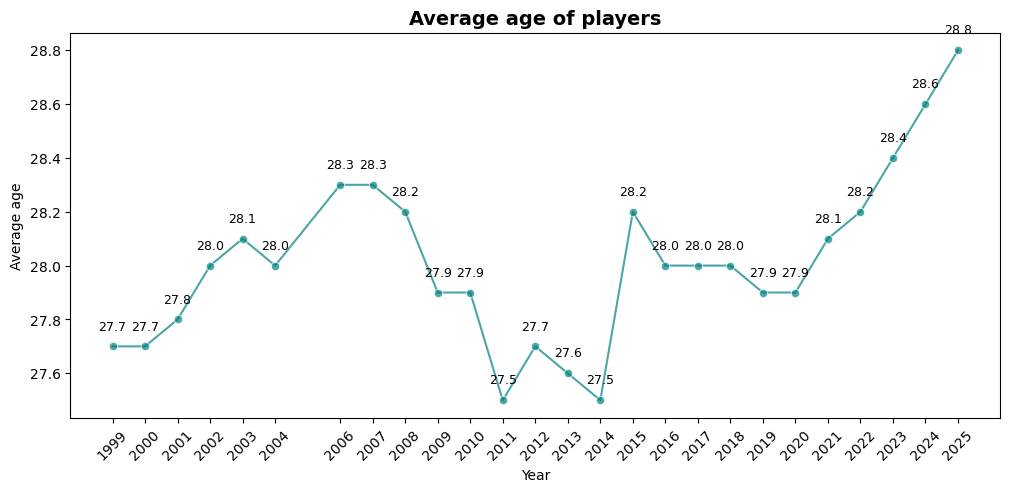

In [31]:
# We only have data about player age from 1999, adjusting the dataframe
league_average_age = league_average[9:]

#Creating the plot
plt.figure(figsize=(12, 5))

ax = sns.lineplot(
    data=league_average_age,
    x="YEAR",
    y="AvAge",
    marker="o",
    alpha=0.7,
    color="teal"
)

# Forcing every year to show on the x axis and rotating them to fit
plt.xticks(league_average_age["YEAR"], rotation=45)

# Looping through the data to show value above the markers
for index, row in league_average_age.iterrows():
    ax.text(
        x=row["YEAR"],
        y=row["AvAge"] + 0.05,
        s=f"{row['AvAge']:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Setting the title of the plot and naming the axes
plt.title("Average age of players", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Average age")

plt.show()

*We can see that average age steadily increases over time with one major drop. The steady increase could potentially be explained by advances in fields that increase player longevity like sport science, nutrition and new specialized training methods. The drop we see from 2006 to 2011 could be potentially caused by the events of 2005 NHL Lockout. After the lockout, salary cap was introduced and it is possible that teams had to let some of the veteran and expensive players go, and fill their spots with young and cheap rookie. These are both just a hypotheses though and would need further analysis to verify*

## Goals per game

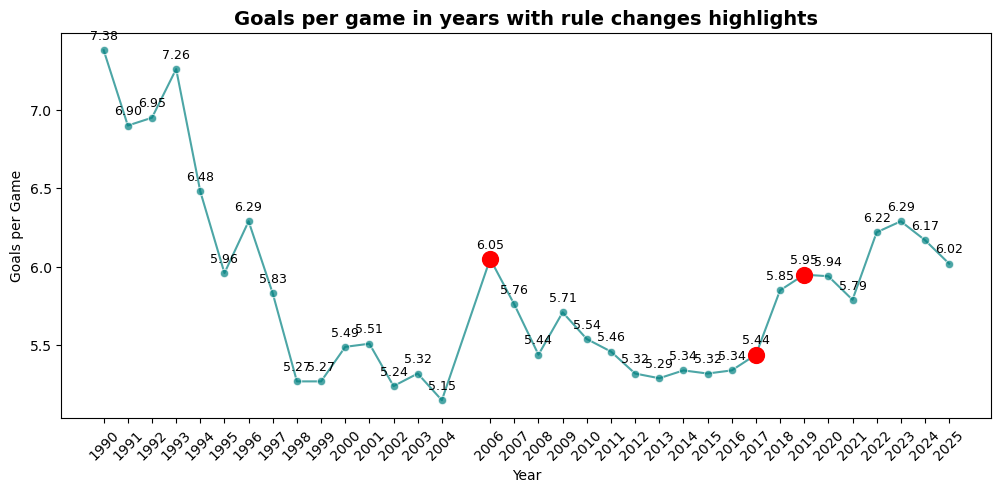

In [32]:
#Creating a line graph to show goals per game evolution in years and highlighting years where rule changes to goal keeper equipment were introduced.

#Creating the plot
plt.figure(figsize=(12, 5))

# Creating the line graph
ax = sns.lineplot(
    data=league_average,
    x="YEAR",
    y="GpG",
    marker="o",
    alpha=0.7,
    color="teal"
)

# Forcing every year to show on the x axis and rotating them to fit
plt.xticks(league_average["YEAR"], rotation=45)

# Looping through the data to show value above the markers
for index, row in league_average.iterrows():
    ax.text(
        x=row["YEAR"],
        y=row["GpG"] + 0.05,
        s=f"{row['GpG']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Years where major rule changes were introduced that changed goalkeeper equipment regulations
highlight_years = [2006, 2017, 2019]

# Filtering the dataframe with just the highlight years
highlights = league_average[league_average["YEAR"].isin(highlight_years)]

# Looping through the highlight data to show value above the markers
for index, row in highlights.iterrows():
    # 2. Draw a larger crimson dot over the specific point
    plt.scatter(
        row["YEAR"], 
        row["GpG"], 
        color="red", 
        s=130, 
        zorder=3
    )

# Setting the title of the plot and naming the axes
plt.title("Goals per game in years with rule changes highlights", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Goals per Game")

plt.show()

*It is interesting to look at this metric because there are two conflicting interests. On one hand the teams want to recieve as little goals as possible to win games, on the other hand the league organizers want there to be a lot of goals scored to keep NHL attractive and profitable. We can again see a jump after the 2005 NHL lockout. One of the results of the lockout was a change in goalkeeper equipment regualtions. The intention was to increase the amount of scored goals that make the game more attractive and to increase viewership. We can also see that the metric started to drop again afterwards, maybe again because of the advances in training methods and sport science. Two more interventions from the side of NHL organizers were made in 2017 and 2019. There is slight drop in Covid years 2020 and 2021, it might be interesting to analyse if the drop could have been directly caused by Covid and the teams perhaps not being able to play with their full rosters. We can see that the metric seems to be on a decline again in 2024 and 2025.It will be interesting to follow if organizers will intervene if the metric drops below 5.3 again. If the trend set in 2024 and 2025 continues, this would happen around year 2030.*

# Determining betting odds

In [33]:
# Defining function for calculating odds
def get_betting_odds(probability):
    return 1 / probability

In [34]:
# Getting total number of wins and games played in the dataframe
total_wins = gr_df["W"].sum()
total_games = gr_df["GP"].sum()

# Calculating global probability
global_win_probability = total_wins / total_games

# Calculating global odds
global_rate = get_betting_odds(global_win_probability)


print(global_win_probability)
print(global_rate.round(2))

0.47444951698741394
2.11


In [35]:
# Defining the league trashholds
a_league = df["WIN%"].quantile(0.95) # Top 5%
b_league = df["WIN%"].quantile(0.70) # Top 30%
c_league = df["WIN%"].quantile(0.20) # Top 80%

# Defining function to assign the teams to their league
def assign_team_to_league(win_pct, top5, top30, top80):
    if win_pct >= top5:
        return "A"
    if win_pct >= top30:
        return "B"
    if win_pct >= top80:
        return "C"
    else:
        return "D"
    
# Creating new column with league rank and assigning it with the function
df["LEAGUE"] = df["WIN%"].apply(lambda x: assign_team_to_league(x, a_league, b_league, c_league))

In [36]:
# Filtering League Average rows out again
df_filtered = df[df["TEAM"]!= "League Average"]

# Defining variable with Wins and Games played for each betting league
bet_league_stats = df_filtered.groupby("LEAGUE")[["W", "GP"]].sum()

# Adding column with win probability for each betting league
bet_league_stats["PROBABILITY"] = bet_league_stats["W"]/bet_league_stats["GP"]

# Adding column with odds for each betting league
bet_league_stats["ODDS"] = bet_league_stats["PROBABILITY"].apply(lambda x: get_betting_odds(x)).round(2)

print(bet_league_stats)

            W     GP  PROBABILITY  ODDS
LEAGUE                                 
A        2692   4064     0.662402  1.51
B       12091  21033     0.574859  1.74
C       17796  38493     0.462318  2.16
D        5042  15704     0.321065  3.11


**Questions for the discussion**

- What elements of the analysis were simplified? What was omitted in the analysis?
    - *There would be many more factors influencing the odds than just the teams win percentage, for example who the team is playing, if their star players are injured, if they are playing at home stadium or away, etc..*

- Are there any inconsistencies in the estimated odds? What are they?
    - *We didn't deal with the seasons from 1990 to 1999 where draws were possible, they are lowering the overall win probability of teams that participated in those seasons*

- How can we improve the odds estimates?
    - *I think that how the team played in 1990 has little to no impact on their odds to win a game tomorrow, we would probably have to take only more recent years into account, along with more data about the team they will face in the game for example and much more data*

- How can we enrich our initial dataset to make the estimates more accurate and less risky?
    - *Teams don't face each other equal amounts of time each season, they are placed in conferences and divisions. We would probably need to include conferences and divisions into the dataset. Team can be in a strong division and have a lower win percentage because it faces strong teams more often, but if they face a team from weaker division, they could be a favourite to win the game based on other metrics.*

- How can we simulate the outcomes of our analysis to verify that they do not lead to financial losses?
    - *below*

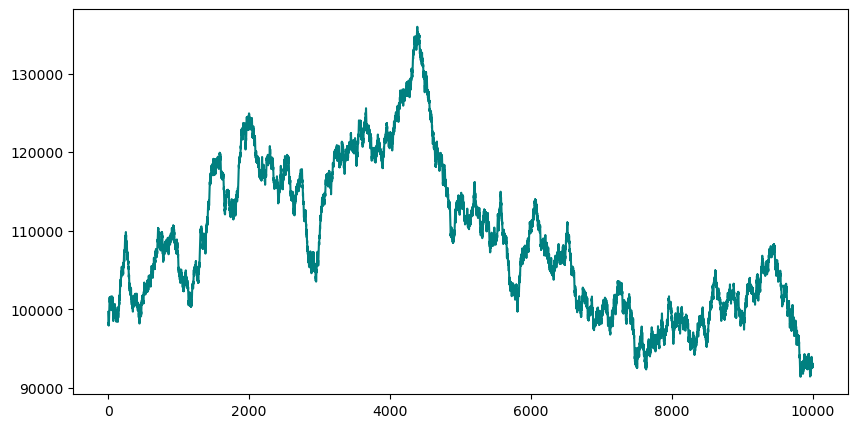

In [37]:
probability = global_win_probability #0.4744
rate = global_rate #2.11
bet_count = 10000 # How many bets we will be simulating
bet_amount = 300  # Size of the bet
capital = 100000 # Starting capital

# Generating random number from 0 to 1 as a result and comparing it to the 0.4744 global probability
match_results = np.random.uniform(0, 1, bet_count) < probability

capital_history = np.zeros(bet_count)
current_capital = capital

for i in range(bet_count):
    capital += bet_amount
    if match_results[i] == True:
        capital -= (bet_amount * rate)

    capital_history[i] = capital

plt.figure(figsize=(10, 5))
plt.plot(capital_history, color="teal", label="Capital")

plt.show()


